In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/suicides_in_india_cleaned_data.csv')

In [3]:
data_by_causes=data[data['type_code']=='Causes']
data_by_Professional_Profile=data[data['type_code']=='Professional_Profile']
data_by_Means_adopted=data[data['type_code']=='Means_adopted']


In [4]:
plt.style.use('classic')

##1. which age group is most affected by suicides?

In [5]:
most_affected_age_group_data=data_by_causes.groupby('age_group')['total'].sum().reset_index()
most_affected_age_group=most_affected_age_group_data.sort_values(by='total',ascending=False).head(1)

most_affected_age_group


,age_group,total
1,15-29,509776


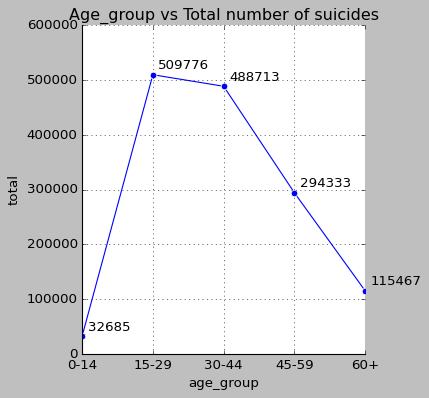

In [8]:
x=most_affected_age_group_data['age_group']
y=most_affected_age_group_data['total']

sns.relplot(data=most_affected_age_group_data,x='age_group',y='total',kind='line',marker='o')

for xi,yi in zip(x,y):
  plt.annotate(text=str(yi),xy=(xi,yi),textcoords='offset points',xytext=(5,5))

plt.grid()
plt.title('Age_group vs Total number of suicides')
#plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/age_group_vs_total_number_of_suicides")
plt.show()

##2. which gender is most affected by suicides?

In [ ]:
most_affected_gender=data_by_causes.groupby('gender')['total'].sum().sort_values(ascending=False).head(1)
most_affected_gender

,total
gender,
Male,923238


##3. which gender+age_group combination is most affected by suicides?

In [9]:
most_affected_age_group_and_gender_data=data_by_causes.groupby(['age_group','gender'])['total'].sum()
most_affected_age_group_and_gender = most_affected_age_group_and_gender_data.reset_index().sort_values(by='total',ascending=False).head(1)

most_affected_age_group_and_gender

,age_group,gender,total
5,30-44,Male,330319


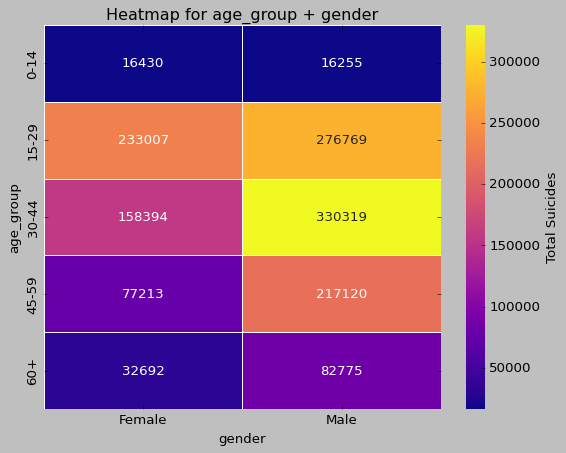

In [10]:
df=most_affected_age_group_and_gender_data.unstack()

sns.heatmap(df,cmap='plasma',annot=True,linewidths=0.5,fmt='d').collections[0].colorbar.set_label('Total Suicides')

plt.title('Heatmap for age_group + gender')
#plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_gender_and_age_group_wise_suicides",bbox_inches='tight')
plt.show()


##4. which top 3 professional profiles are most affected?

In [11]:
most_affected_age_profession_data=data_by_Professional_Profile.groupby('type')['total'].sum().sort_values(ascending=False).reset_index()
most_affected_age_profession_data.head(3)

,type,total
0,Others (Please Specify),469147
1,House Wife,285243
2,Farming/Agriculture Activity,197923


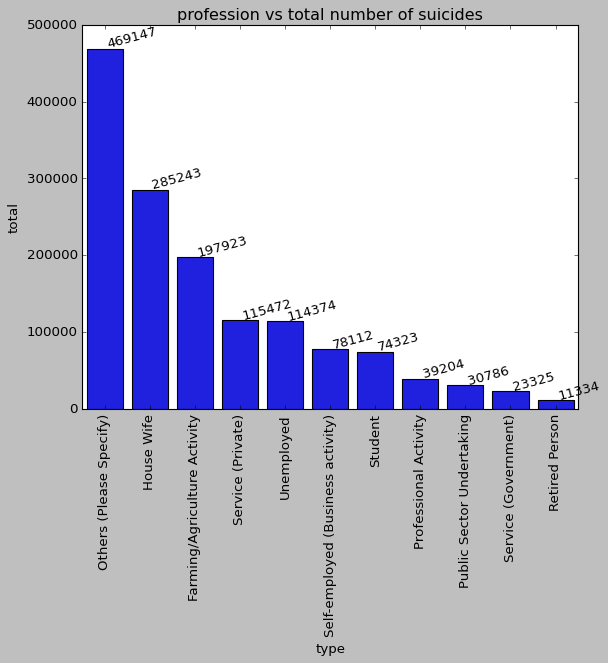

In [12]:
sns.barplot(data=most_affected_age_profession_data,x='type',y='total',)

x=most_affected_age_profession_data['type']
y=most_affected_age_profession_data['total']
for xi,yi in zip(x,y):
  plt.annotate(text=str(yi),xy=(xi,yi),textcoords='offset points',xytext=(1,1),rotation=15)

plt.xticks(x,x,rotation=90)
plt.title('profession vs total number of suicides')
#plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/profession_vs_total_number_of_suicides",bbox_inches='tight')
plt.show()

##5. which top 5 gender+professional_profile combination is most affected?

In [13]:
most_affected_gender_and_peofessional_profile_data = data_by_Professional_Profile.groupby(['type','gender'])['total'].sum()
most_affected_gender_and_peofessional_profile = most_affected_gender_and_peofessional_profile_data.reset_index().sort_values(by='total',ascending=False).head()

most_affected_gender_and_peofessional_profile

,type,gender,total
4,Others (Please Specify),Male,357956
2,House Wife,Female,285243
1,Farming/Agriculture Activity,Male,170623
3,Others (Please Specify),Female,111191
16,Service (Private),Male,96850


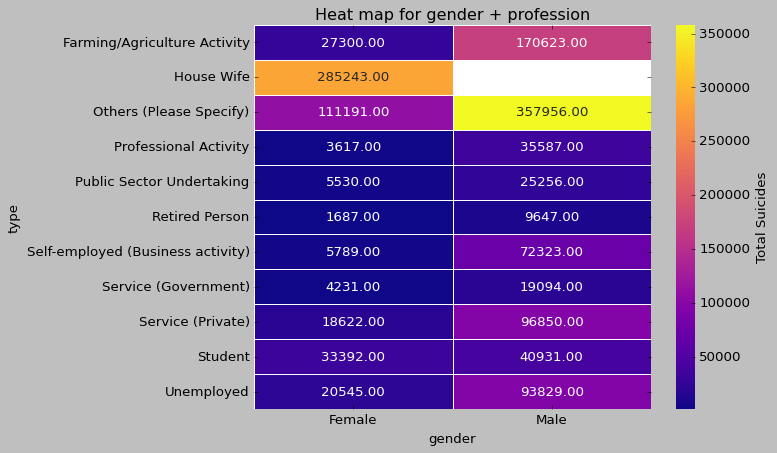

In [15]:
df=most_affected_gender_and_peofessional_profile_data.unstack()

sns.heatmap(df,cmap='plasma',annot=True,linewidths=0.5,fmt='0.2f').collections[0].colorbar.set_label('Total Suicides')

plt.title('Heat map for gender + profession')
#plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_gender_and_profession_wise_suicides",bbox_inches='tight')
plt.show()

##6. year wise most affected age_group, gender, gender+age_group, professional_profile, professional_profile+age_group.

###year wise most affeted age_group


In [16]:
# year wise most affeted age_group

temp_df=data_by_causes.groupby(['year','age_group'])['total'].max().unstack()
temp_age_group=temp_df.idxmax(axis=1)
temp_values=temp_df.max(axis=1)

year_wise_most_affected_age_gruop_data = pd.DataFrame({"age_group":temp_age_group,"total":temp_values})

year_wise_most_affected_age_gruop_data

,age_group,total
year,,
2001,30-44,1122
2002,30-44,1189
2003,30-44,1274
2004,15-29,1175
2005,15-29,1150
2006,30-44,1465
2007,15-29,1258
2008,30-44,1249
2009,30-44,1240


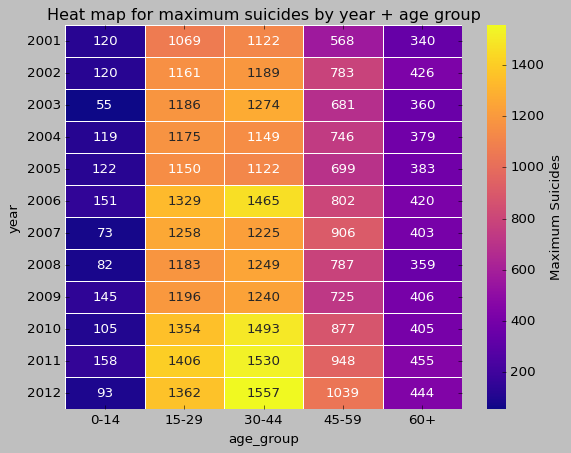

In [18]:
# year and age_group wise max data heatmap

year_and_age_group_wise_maxvalue_data = data_by_causes.groupby(['year','age_group'])['total'].max().unstack()

sns.heatmap(year_and_age_group_wise_maxvalue_data,annot=True,fmt='d',cmap='plasma',linewidths=0.5).collections[0].colorbar.set_label('Maximum Suicides')

plt.title('Heat map for maximum suicides by year + age group')
#plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_maximum_suicides_by_year_and_age_group",bbox_inches='tight')
plt.show()

###year wise most affected gender

In [19]:
# year wise most affected gender

year_wise_most_affected_gender_data=data_by_causes.groupby(['year','gender'])['total'].sum().unstack()
year_wise_most_affected_gender_data['Most affected gender']=year_wise_most_affected_gender_data.idxmax(axis=1)
year_wise_most_affected_gender_data

gender,Female,Male,Most affected gender
year,,,
2001,42192,66314,Male
2002,41085,69332,Male
2003,40630,70221,Male
2004,41046,72651,Male
2005,40998,72916,Male
2006,42410,75702,Male
2007,43342,79295,Male
2008,44473,80544,Male
2009,45680,81471,Male


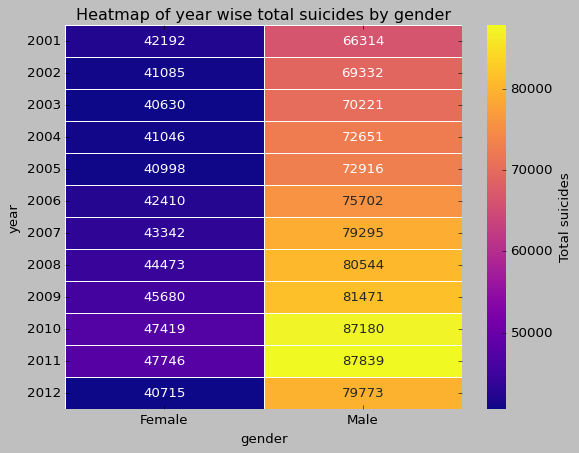

In [21]:
# heatmap of year wise total suicides by gender

df=year_wise_most_affected_gender_data.drop(columns=['Most affected gender'])
sns.heatmap(df,annot=True,fmt='d',linewidths=0.5,cmap='plasma').collections[0].colorbar.set_label('Total suicides')

plt.title('Heatmap of year wise total suicides by gender')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_year_and_gender_wise_total_suicides",bbox_inches='tight')
plt.show()

### year wise most affected gender+age_group

In [22]:
# year wise most affected gender+age_group

year_wise_gender_and_age_group_data=data_by_causes.groupby(['year','gender','age_group'])['total'].sum().unstack()
year_wise_most_affected_gender_and_age_group=year_wise_gender_and_age_group_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected age_group'})

year_wise_most_affected_gender_and_age_group

most affected age_group
year gender                        
2001 Female                   15-29
     Male                     30-44
2002 Female                   15-29
     Male                     30-44
2003 Female                   15-29
     Male                     30-44
2004 Female                   15-29
     Male                     30-44
2005 Female                   15-29
     Male                     30-44
2006 Female                   15-29
     Male                     30-44
2007 Female                   15-29
     Male                     30-44
2008 Female                   15-29
     Male                     30-44
2009 Female                   15-29
     Male                     30-44
2010 Female                   15-29
     Male                     30-44
2011 Female                   15-29
     Male                     30-44
2012 Female                   15-29
     Male                     30-44

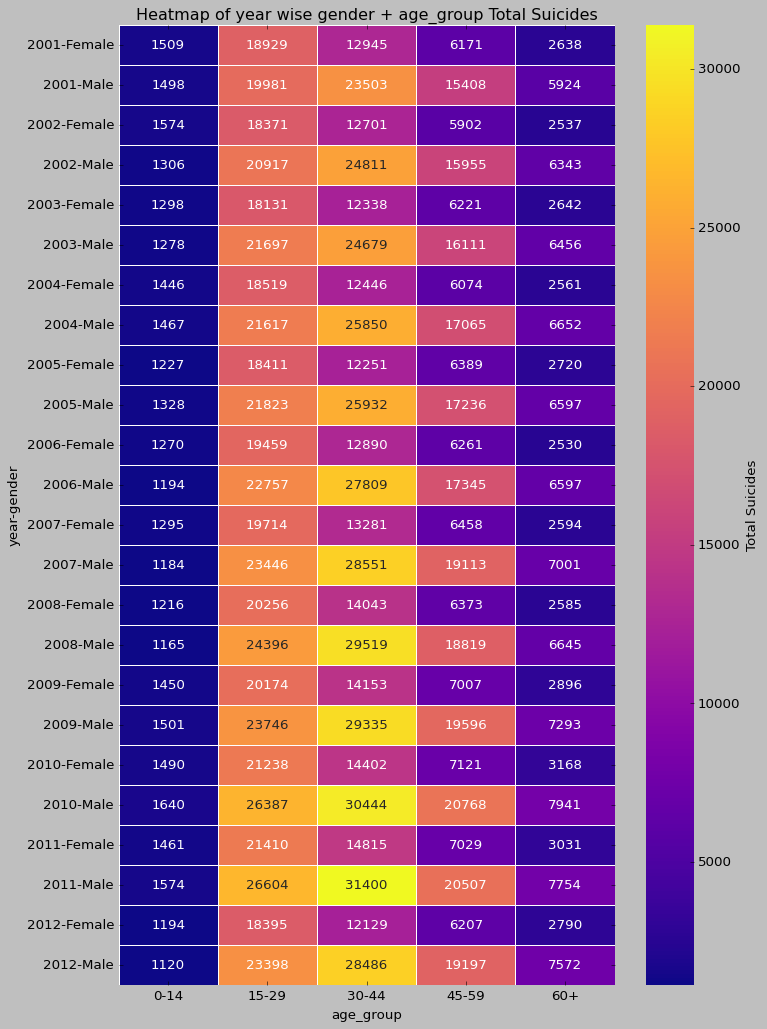

In [24]:
# heatmap of year wise gender+age_group
plt.figure(figsize=(10,15))
sns.heatmap(year_wise_gender_and_age_group_data,annot=True,fmt='d',linewidths=0.5,cmap='plasma').collections[0].colorbar.set_label('Total Suicides')
plt.title('Heatmap of year wise gender + age_group Total Suicides')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_year_wise_gender_+_age_group_Total_Suicides",bbox_inches='tight')
plt.show()

### year wise most affected profession (ignore others)

In [25]:
# year wise most affected profession (ignore others)

df=data_by_Professional_Profile[data_by_Professional_Profile['type']!='Others (Please Specify)']

year_and_profession_wise_suicides_data=df.groupby(['year','type'])['total'].sum().unstack()

year_wise_most_affeted_profession=year_and_profession_wise_suicides_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected profession (others ignored)'})

year_wise_most_affeted_profession

,most affected profession (others ignored)
year,
2001,House Wife
2002,House Wife
2003,House Wife
2004,House Wife
2005,House Wife
2006,House Wife
2007,House Wife
2008,House Wife
2009,House Wife


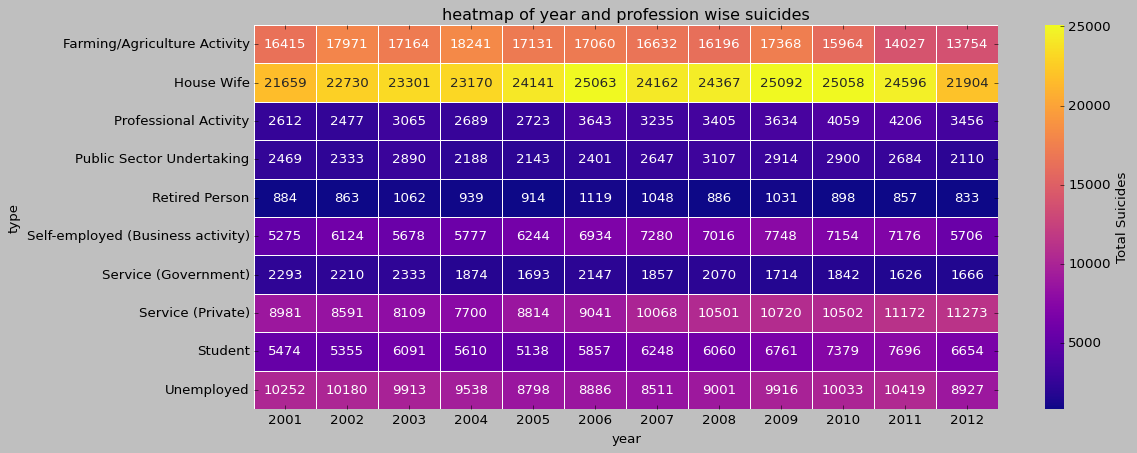

In [27]:
# heatmap of year and profession wise suicides
plt.figure(figsize=(15,6))
sns.heatmap(year_and_profession_wise_suicides_data.T,annot=True,fmt='d',linewidths=0.5,cmap='plasma').collections[0].colorbar.set_label("Total Suicides")
plt.title('heatmap of year and profession wise suicides')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_year_and_profession_wise_suicides",bbox_inches='tight')
plt.show()


### year wise most affected profession + age_group (ignore others)

In [28]:
df=data_by_Professional_Profile[data_by_Professional_Profile['type']!='Others (Please Specify)']
year_wise_profession_and_age_group_data=df.groupby(['year','type','age_group'])['total'].sum().unstack('type')

year_wise_most_affected_profession_and_age_group=year_wise_profession_and_age_group_data.unstack().idxmax(axis=1).to_frame().rename(columns={0:'most affected profession+age_group'})

year_wise_most_affected_profession_and_age_group

,most affected profession+age_group
year,
2001,"(House Wife, 15-29)"
2002,"(House Wife, 15-29)"
2003,"(House Wife, 15-29)"
2004,"(House Wife, 15-29)"
2005,"(House Wife, 15-29)"
2006,"(House Wife, 15-29)"
2007,"(House Wife, 15-29)"
2008,"(House Wife, 15-29)"
2009,"(House Wife, 15-29)"


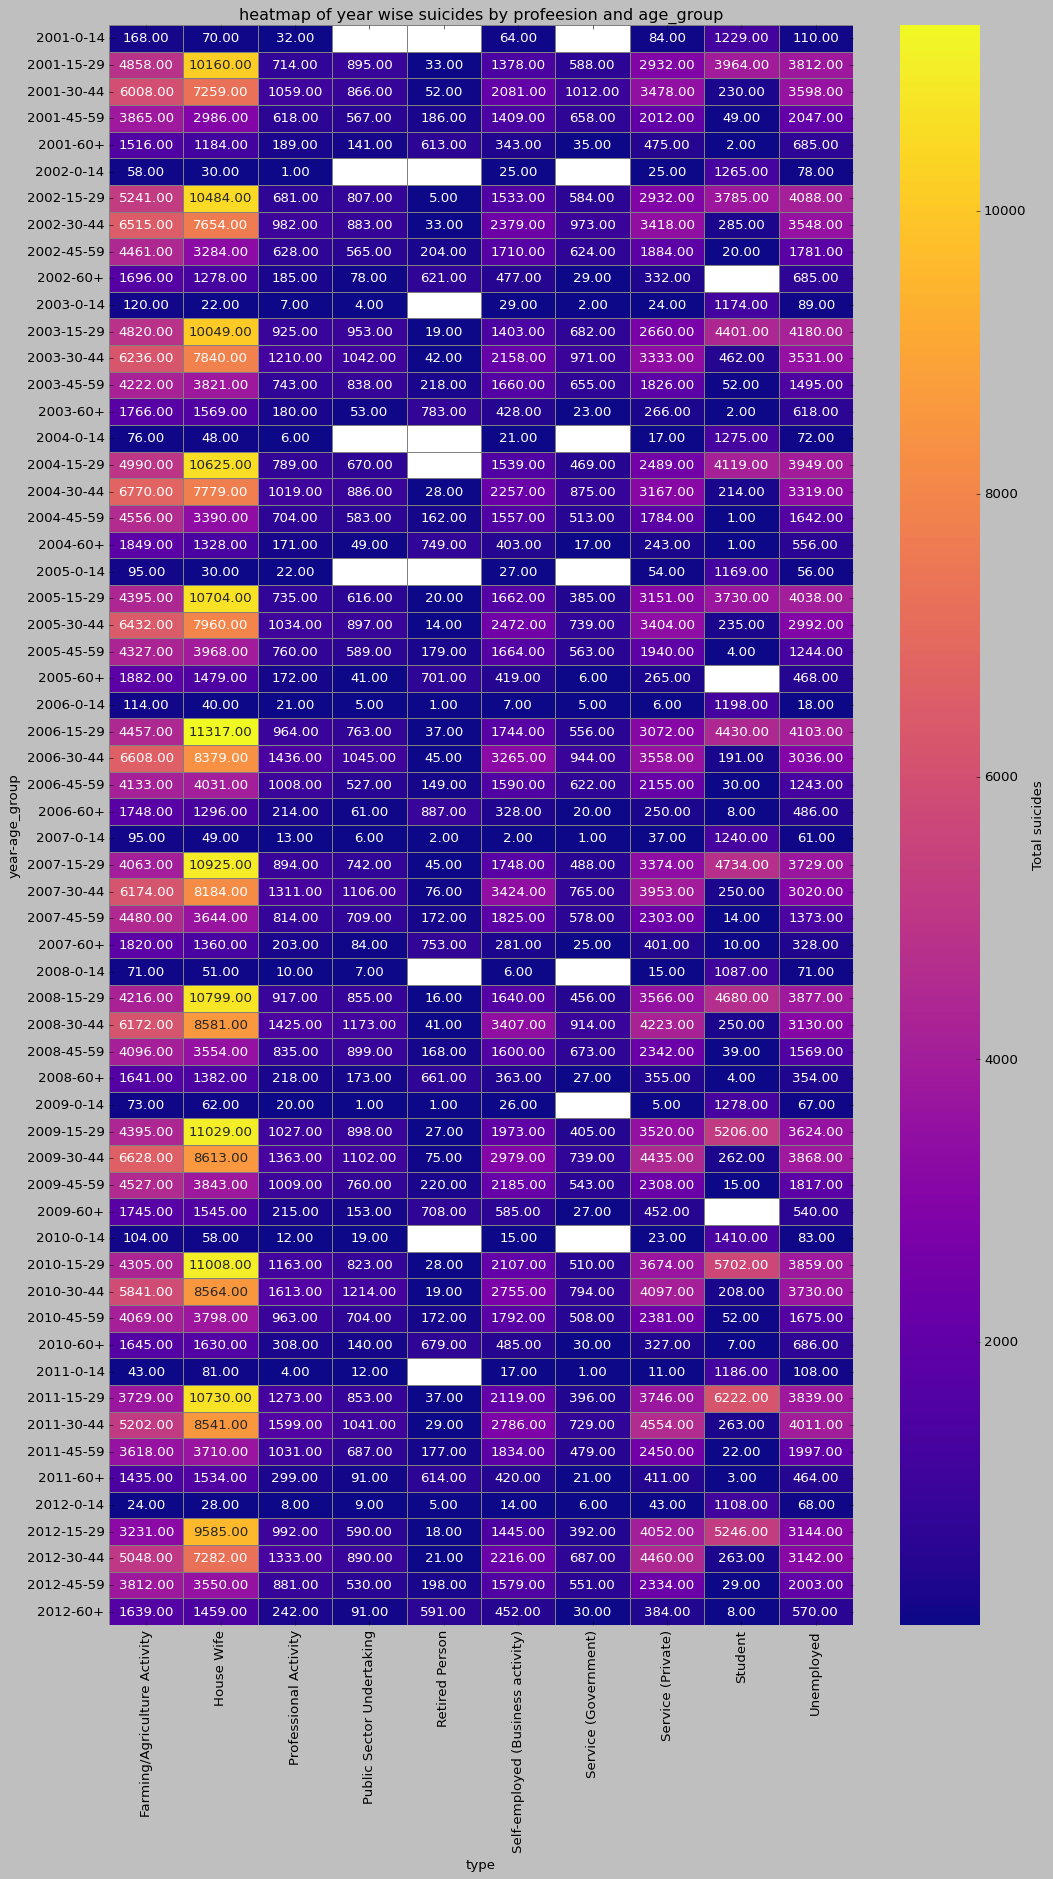

In [41]:
# heatmap of year wise suicides by profeesion and age_group
plt.figure(figsize=(15,25))
sns.heatmap(year_wise_profession_and_age_group_data,cmap='plasma',linewidths=0.5,annot=True,fmt='0.2f',linecolor='grey').collections[0].colorbar.set_label('Total suicides')
plt.title('heatmap of year wise suicides by profeesion and age_group')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_year_wise_suicides_by_profession_and_age_group",bbox_inches='tight')
plt.show()

##7. state wise most affected age_group, gender, gender+age_group, professional_profile.

### state wise most affected age_group

In [30]:
# state wise most affected age_group
state_and_age_group_wise_data=data_by_causes.groupby(['state','age_group'])['total'].sum().unstack()
state_wise_most_affected_age_group=state_and_age_group_wise_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected age_group'})
state_wise_most_affected_age_group

,most affected age_group
state,
A & N Islands,15-29
Andhra Pradesh,30-44
Arunachal Pradesh,15-29
Assam,15-29
Bihar,15-29
Chandigarh,15-29
Chhattisgarh,15-29
D & N Haveli,15-29
Daman & Diu,15-29


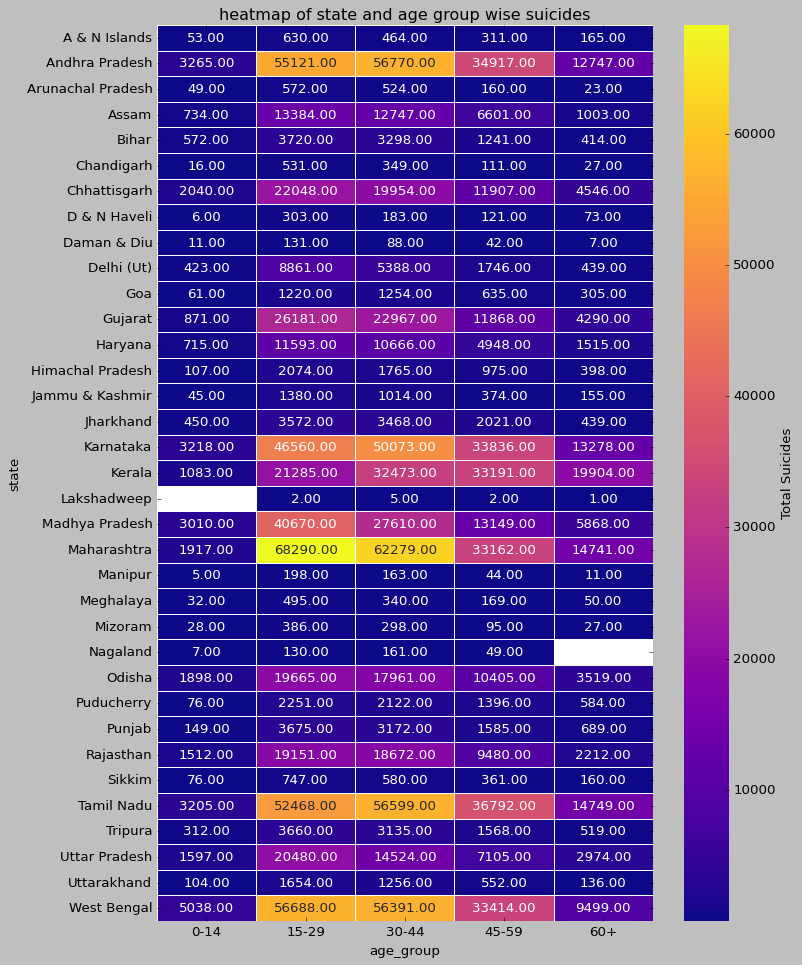

In [31]:
# heatmap of state and age group wise suicides
plt.figure(figsize=(10,14))
sns.heatmap(state_and_age_group_wise_data,annot=True,fmt='0.2f',cmap='plasma',linewidths=0.5).collections[0].colorbar.set_label("Total Suicides")
plt.title("heatmap of state and age group wise suicides")
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_state_and_age_group_wise_suicides",bbox_inches='tight')
plt.show()

### state wise most affected gender

In [32]:
# state wise most affected gender
state_and_gender_wise_data=data_by_causes.groupby(['state','gender'])['total'].sum().unstack()

state_wise_most_affected_gender=state_and_gender_wise_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected gender'})

state_wise_most_affected_gender

,most affected gender
state,
A & N Islands,Male
Andhra Pradesh,Male
Arunachal Pradesh,Male
Assam,Male
Bihar,Male
Chandigarh,Male
Chhattisgarh,Male
D & N Haveli,Male
Daman & Diu,Male


In [33]:
state_and_gender_wise_data

gender,Female,Male
state,,
A & N Islands,550,1073
Andhra Pradesh,54396,108424
Arunachal Pradesh,391,937
Assam,11031,23438
Bihar,4053,5192
Chandigarh,378,656
Chhattisgarh,19739,40756
D & N Haveli,280,406
Daman & Diu,95,184


### state wise most affected gender+age_group

In [34]:
# state wise most affected gender + age_group
state_and_gender_and_age_group_wise_data=data_by_causes.groupby(['state','gender','age_group'])['total'].sum().unstack().unstack()

state_wise_most_affected_gender_and_age_group=state_and_gender_and_age_group_wise_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected age-group+gender'})

state_wise_most_affected_gender_and_age_group

,most affected age-group+gender
state,
A & N Islands,"(15-29, Male)"
Andhra Pradesh,"(30-44, Male)"
Arunachal Pradesh,"(30-44, Male)"
Assam,"(30-44, Male)"
Bihar,"(15-29, Male)"
Chandigarh,"(15-29, Male)"
Chhattisgarh,"(30-44, Male)"
D & N Haveli,"(15-29, Female)"
Daman & Diu,"(15-29, Male)"


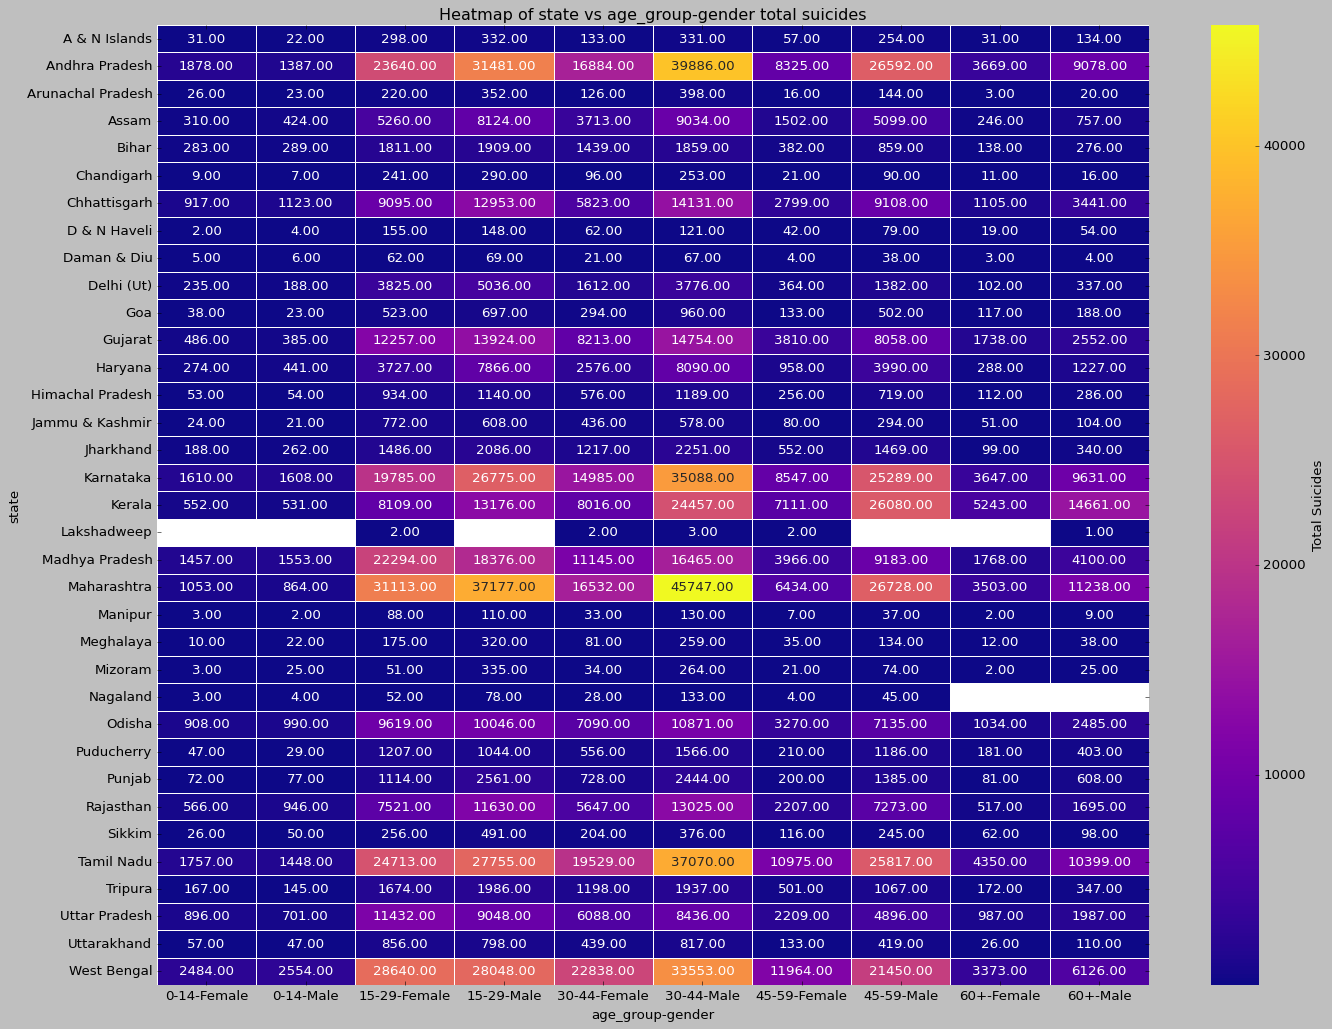

In [35]:
# heatmap of state,gender,agegroup wise suicides
plt.figure(figsize=(20,15))
sns.heatmap(state_and_gender_and_age_group_wise_data,annot=True,fmt='0.2f',linewidths=0.5,cmap='plasma').collections[0].colorbar.set_label('Total Suicides')
plt.title('Heatmap of state vs age_group-gender total suicides')
#plt.savefig("/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/Heatmap_of_state,gender,age_group_wise_total_suicides",bbox_inches='tight')
plt.show()

### state wise most affected profession

In [42]:
# state wise most affected profession(with considered others)

state_and_profession_wise_data=data_by_Professional_Profile.groupby(['state','type'])['total'].sum().unstack()

state_wise_most_affected_profession=state_and_profession_wise_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected profeesionn'})
state_wise_most_affected_profession

,most affected profeesionn
state,
A & N Islands,Service (Private)
Andhra Pradesh,Others (Please Specify)
Arunachal Pradesh,Others (Please Specify)
Assam,Others (Please Specify)
Bihar,Others (Please Specify)
Chandigarh,House Wife
Chhattisgarh,Others (Please Specify)
D & N Haveli,House Wife
Daman & Diu,Service (Private)


In [43]:
# state wise most affected profession(ignore others)

state_and_profession_wise_data=data_by_Professional_Profile[data_by_Professional_Profile['type']!='Others (Please Specify)'].groupby(['state','type'])['total'].sum().unstack()

state_wise_most_affected_profession=state_and_profession_wise_data.idxmax(axis=1).to_frame().rename(columns={0:'most affected profeesionn'})
state_wise_most_affected_profession

,most affected profeesionn
state,
A & N Islands,Service (Private)
Andhra Pradesh,House Wife
Arunachal Pradesh,House Wife
Assam,House Wife
Bihar,House Wife
Chandigarh,House Wife
Chhattisgarh,Farming/Agriculture Activity
D & N Haveli,House Wife
Daman & Diu,Service (Private)


### state wise most affected profession+age_group heatmap

In [38]:
states=data_by_Professional_Profile['state'].unique()
professions_without_others=data_by_Professional_Profile[data_by_Professional_Profile['type']!='Others (Please Specify)']['type'].unique()
ages=data_by_Professional_Profile['age_group'].unique()

In [39]:
profession_and_age_group_wise_data_dict={}
for state in states:
  df=data_by_Professional_Profile[data_by_Professional_Profile['state']==state]
  profession_and_age_group_wise_data_dict[state]=df.groupby(['type','age_group'])['total'].sum().unstack()

In [44]:
for state in states:
  sns.heatmap(profession_and_age_group_wise_data_dict[state],annot=True,fmt='0.2f',linewidths=0.5,cmap='plasma').collections[0].colorbar.set_label('Total Suicides')
  plt.title(f"profession vs age_group wise suicides Heatmap for {state}")

  #plt.savefig(f"/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/Charts/Heatmaps/state wise most affected profession+age_group heatmap/profession_vs_age_group_wise_suicides_Heatmap_for_{state.replace(" ","_")}",bbox_inches='tight')
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

##8. top 10 most affected gender+professional_profile+age_group combination.
ignore others profession category

In [45]:
df=data_by_Professional_Profile[data_by_Professional_Profile['type']!='Others (Please Specify)']
df.groupby(['type','age_group','gender'])['total'].sum().reset_index().sort_values(by='total',ascending=False).head(10).reset_index(drop=True)

,type,age_group,gender,total
0,House Wife,15-29,Female,127415
1,House Wife,30-44,Female,96636
2,Farming/Agriculture Activity,30-44,Male,64287
3,Farming/Agriculture Activity,45-59,Male,45070
4,House Wife,45-59,Female,43579
5,Farming/Agriculture Activity,15-29,Male,42205
6,Service (Private),30-44,Male,40103
7,Unemployed,15-29,Male,35783
8,Unemployed,30-44,Male,34765
9,Student,15-29,Male,31332
